In [1]:
!pip install ./acosp/
!pip install ./segsem/
# !./download_model.sh

Processing ./acosp
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for acosp: filename=acosp-1.0.0-py3-none-any.whl size=13828 sha256=20e560233700fd451f067690c7ea7a914839349775bf8f6416bf7408fdc00713
  Stored in directory: /tmp/pip-ephem-wheel-cache-leziw414/wheels/a4/3c/53/91712c27ddcf1f70befa7b6c5efcc88b35cdbff1890ce41ddf
Successfully built acosp
  Attempting uninstall: acosp
    Found existing installation: acosp 1.0.0
    Uninstalling acosp-1.0.0:
      Successfully uninstalled acosp-1.0.0
ERROR: Invalid requirement: './segsem/'
Hint: It looks like a path. File './segsem/' does not exist.


In [2]:
# System libs
import os, csv, torch, numpy, scipy.io, PIL.Image, torchvision.transforms
# Our libs
from mit_semseg.models import ModelBuilder, SegmentationModule
from mit_semseg.utils import colorEncode

colors = scipy.io.loadmat('data/color150.mat')['colors']
names = {}
with open('data/object150_info.csv') as f:
    reader = csv.reader(f)
    next(reader)
    for row in reader:
        names[int(row[0])] = row[5].split(";")[0]

def visualize_result(img, pred, index=None):
    # filter prediction class if requested
    if index is not None:
        pred = pred.copy()
        pred[pred != index] = -1
        print(f'{names[index+1]}:')
        
    # colorize prediction
    pred_color = colorEncode(pred, colors).astype(numpy.uint8)

    # aggregate images and save
    im_vis = numpy.concatenate((img, pred_color), axis=1)
    display(PIL.Image.fromarray(im_vis))

In [3]:
def train(num_epoch=20, start_epoch=0, epoch_iters=5000, cfg='config/ade20k-resnet50dilated-ppm_deepsup.yaml', prune=True, ratio=1, opts='', silent=False, prune=True):
    if silent and prune:
        !python3 train_prune.py --gpus 0 --cfg {cfg} --ratio {ratio} TRAIN.num_epoch {num_epoch} TRAIN.start_epoch {start_epoch} TRAIN.epoch_iters {epoch_iters} {opts} > /dev/null
    elif prune:
        !python3 train_prune.py --gpus 0 --cfg {cfg} --ratio {ratio} TRAIN.num_epoch {num_epoch} TRAIN.start_epoch {start_epoch} TRAIN.epoch_iters {epoch_iters} {opts}
    elif silent:
        !!python3 train_prune.py --gpus 0 --cfg {cfg} TRAIN.num_epoch {num_epoch} TRAIN.start_epoch {start_epoch} TRAIN.epoch_iters {epoch_iters} {opts}

In [4]:
def evaluate(cfg='config/ade20k-resnet50dilated-ppm_deepsup.yaml', opts="", file=None):
    if file:
        !python3 eval_multipro.py --gpus 0 --cfg {cfg} {opts} > {file}
    else:
        !python3 eval_multipro.py --gpus 0 --cfg {cfg} {opts}

In [5]:
def test(path, cfg='config/ade20k-resnet50dilated-ppm_deepsup.yaml' , opts=""):
    !python3 -u test.py --imgs {path} --gpu 0 --cfg {cfg} {opts}

# Punning the model

In [6]:
train(num_epoch=21, epoch_iters=1, start_epoch=20, ratio=0.3)
# !python3 train_prune.py --gpus 0 --cfg config/ade20k-resnet50dilated-ppm_deepsup.yaml

/home/mjmaza/cv-project/train_prune.py:223: DeprecationWarning: distutils Version classes are deprecated. Use packaging.version instead.
  assert LooseVersion(torch.__version__) >= LooseVersion('0.4.0'), \
[2025-05-11 23:55:31,453 INFO train_prune.py line 263 1003] Loaded configuration file config/ade20k-resnet50dilated-ppm_deepsup.yaml
[2025-05-11 23:55:31,453 INFO train_prune.py line 264 1003] Running with config:
DATASET:
  imgMaxSize: 1000
  imgSizes: (300, 375, 450, 525, 600)
  list_train: ./data/training.odgt
  list_val: ./data/validation.odgt
  num_class: 150
  padding_constant: 8
  random_flip: True
  root_dataset: ./data/
  segm_downsampling_rate: 8
DIR: ckpt/ade20k-resnet50dilated-ppm_deepsup
MODEL:
  arch_decoder: ppm_deepsup
  arch_encoder: resnet50dilated
  fc_dim: 2048
  weights_decoder: 
  weights_encoder: 
TEST:
  batch_size: 1
  checkpoint: epoch_20.pth
  result: ./
TRAIN:
  batch_size_per_gpu: 2
  beta1: 0.9
  deep_sup_scale: 0.4
  disp_iter: 20
  epoch_iters: 1
  fix

In [7]:
net_encoder = ModelBuilder.build_encoder(
    arch='resnet50dilated',
    fc_dim=2048,
    weights='ckpt/ade20k-resnet50dilated-ppm_deepsup/encoder_epoch_25.pth')
net_decoder = ModelBuilder.build_decoder(
    arch='ppm_deepsup',
    fc_dim=2048,
    num_class=150,
    weights='ckpt/ade20k-resnet50dilated-ppm_deepsup/decoder_epoch_25.pth',
    use_softmax=True)

crit = torch.nn.NLLLoss(ignore_index=-1)
module = SegmentationModule(net_encoder, net_decoder, crit)
module.eval()
module.cuda()

Loading weights for net_encoder
Loading weights for net_decoder


SegmentationModule(
  (encoder): ResnetDilated(
    (conv1): Conv2d(3, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (bn1): SynchronizedBatchNorm2d(64, eps=1e-05, momentum=0.001, affine=True, track_running_stats=True)
    (relu1): ReLU(inplace=True)
    (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn2): SynchronizedBatchNorm2d(64, eps=1e-05, momentum=0.001, affine=True, track_running_stats=True)
    (relu2): ReLU(inplace=True)
    (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn3): SynchronizedBatchNorm2d(128, eps=1e-05, momentum=0.001, affine=True, track_running_stats=True)
    (relu3): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(128, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): SynchronizedBatchNorm2d(64, eps=1

In [9]:
def sparsity(module):
    print(
    "Sparsity in conv1.weight: {:.2f}%".format(
        100. * float(torch.sum(module.weight == 0))
        / float(module.weight.nelement())
    )
)
sparsity(module.encoder.conv1)

Sparsity in conv1.weight: 33.33%


In [10]:
pil_to_tensor = torchvision.transforms.Compose([
    torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize(
        mean=[0.485, 0.456, 0.406], # These are RGB mean+std values
        std=[0.229, 0.224, 0.225])  # across a large photo dataset.
])
pil_image = PIL.Image.open('ADE_val_00001519.jpg').convert('RGB')
img_original = numpy.array(pil_image)
img_data = pil_to_tensor(pil_image)
singleton_batch = {'img_data': img_data[None].cuda()}
output_size = img_data.shape[1:]

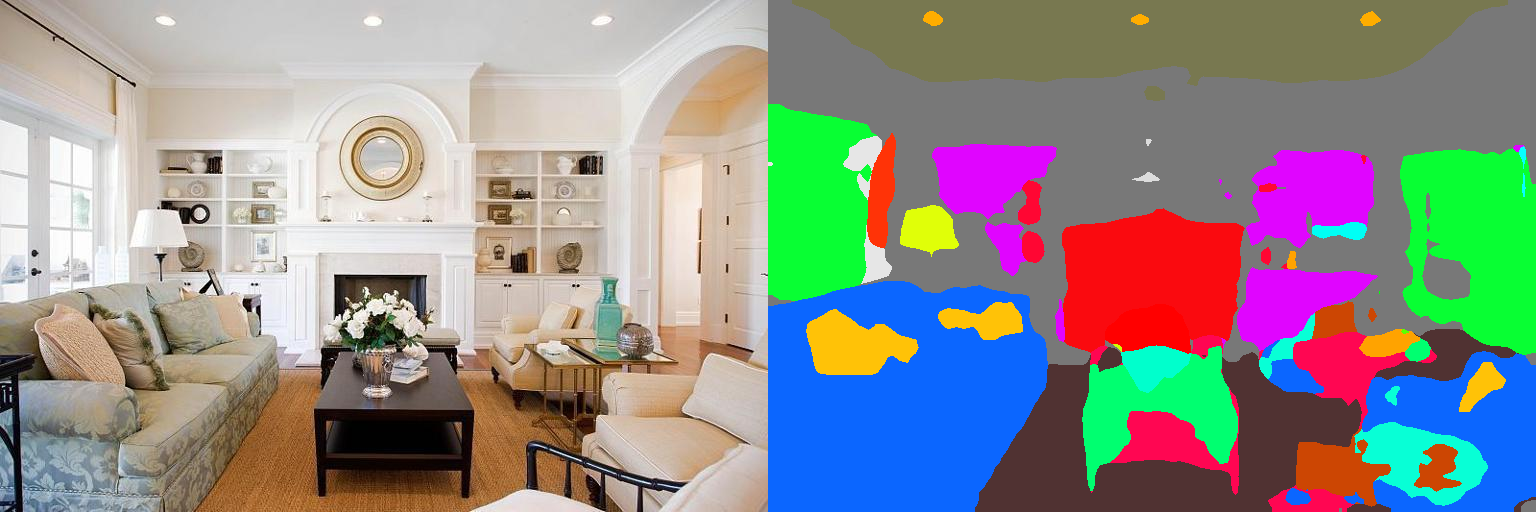

In [11]:
# Run the segmentation at the highest resolution.
with torch.no_grad():
    scores = module(singleton_batch, segSize=output_size)
    
# Get the predicted scores for each pixel
_, pred = torch.max(scores, dim=1)
pred = pred.cpu()[0].numpy()
visualize_result(img_original, pred)

In [ ]:
# Top classes in answer
predicted_classes = numpy.bincount(pred.flatten()).argsort()[::-1]
for c in predicted_classes[:15]:
    visualize_result(img_original, pred, c)

In [11]:
test_ratios = [0.7, 0.5, 0.3]
for r in test_ratios:
    print(f"Testing ratio: {r}")
    train(num_epoch=25, start_epoch=20, epoch_iters=2500, ratio=r, silent=True)
    evaluate(opts='VAL.checkpoint epoch_25.pth', file=f"./eval/eval_{r}.txt")
    print("Checkpointing prune only")
    train(num_epoch=30, start_epoch=25, epoch_iters=2500, prune=False, silent=True)
    evaluate(opts='VAL.checkpoint epoch_30.pth', file=f"./eval/eval_{r}_fine.txt")
print("Done!")

Testing ratio: 0.7
/home/mjmaza/cv-project/train_prune.py:223: DeprecationWarning: distutils Version classes are deprecated. Use packaging.version instead.
  assert LooseVersion(torch.__version__) >= LooseVersion('0.4.0'), \
/home/mjmaza/cv-project/eval_multipro.py:178: DeprecationWarning: distutils Version classes are deprecated. Use packaging.version instead.
  assert LooseVersion(torch.__version__) >= LooseVersion('0.4.0'), \
100%|█████████████████████████████████████████| 100/100 [00:30<00:00,  3.31it/s]
Checkpointing prune only
/home/mjmaza/cv-project/train_prune.py:223: DeprecationWarning: distutils Version classes are deprecated. Use packaging.version instead.
  assert LooseVersion(torch.__version__) >= LooseVersion('0.4.0'), \
/home/mjmaza/cv-project/eval_multipro.py:178: DeprecationWarning: distutils Version classes are deprecated. Use packaging.version instead.
  assert LooseVersion(torch.__version__) >= LooseVersion('0.4.0'), \
100%|█████████████████████████████████████████|

In [13]:
evaluate(opts='VAL.checkpoint epoch_20.pth', file=f"./eval/eval_{0.0}.txt")

/home/mjmaza/cv-project/eval_multipro.py:178: DeprecationWarning: distutils Version classes are deprecated. Use packaging.version instead.
  assert LooseVersion(torch.__version__) >= LooseVersion('0.4.0'), \
100%|█████████████████████████████████████████| 100/100 [00:29<00:00,  3.34it/s]
